# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Calculation of Fibonacci Ratios

You have seen how fibonacci ratios are present everywhere in nature, and how it can show up in the trading domain as well. In this notebook, you are going to calculate and plot the fibonacci levels using Apple stock price data.

The notebook is structured as follows:
1. [Import the Libraries](#import)
2. [Import the Data](#get)
3. [Calculation of Fibonacci Ratios](#fibo_cal)
4. [Plot the Fibonacci Ratios](#plot)
5. [Summary](#summary)

<a id='import'></a>
## Import Libraries

You will use the `pandas` library to store as well as perform various calculations on the price data. Further, you will use the `matplotlib` library to plot the fibonacci ratios as well as the price data.

In [1]:
# For data manipulation
import pandas as pd

# For data visualisation
import matplotlib.pyplot as plt
%matplotlib inline

# For warning suppression
import warnings
warnings.filterwarnings("ignore")

<a id='get'></a>
## Import the Data
You will import the file `aapl_daily_data_april_2019_april_2020.csv` which contains the daily price data of the Apple stock for the period of one year i.e. April 2019 to April 2020. The choice of one year data is arbitrary and can be changed depending on your requirements.

This price data will be stored in a dataframe named `data`.

You will use the `read_csv` method of `pandas` to import this file.

**Note:** This file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Read CSV file using read_csv method of pandas
data = pd.read_csv(
    '../data_modules/aapl_daily_data_april_2019_april_2020.csv', index_col=0)

# Convert the index to datetime
data.index = pd.to_datetime(data.index)

# Print the first 5 rows of Apple price data
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-06-14,47.887501,48.397499,47.575001,48.185001,46.964100,75046000
2019-06-17,48.224998,48.740002,48.042500,48.472500,47.244308,58676400
2019-06-18,49.012501,50.072498,48.802502,49.612499,48.355434,106204000
2019-06-19,49.919998,49.970001,49.327499,49.467499,48.214100,84496800
2019-06-20,50.092499,50.152500,49.507500,49.865002,48.601532,86056000


<a id='fibo_cal'></a>
## Fibonacci Ratios

In order to calculate the fibonacci ratios, you need to identify the minimum and maximum price of the asset which you are analysing. This will help you to find the range between which the fibonacci ratios are calculated.

### How do you identify the minimum and maximum price?

You can use the `low` column of the OHLCV data to find the minimum price. Similarly, you can use the `High` column of the OHLCV data to find the maximum price of the datset.
If you are working with candlesticks data, you can use the `Low` and `High` price of the OHLCV dataset. And if you are going to plot line chart patterns, you can use the `Close` prices of the dataset. 

For this notebook, we are using the close prices of the dataset. This choice is arbitrary and can be changed.

Once you have identified the minimum and maximum price, you can move forward and calculate the fibonacci ratios. These fibonacci levels are 23.6%, 38.2%, 50%, 61.8% and 78.6% of the range (maximum price - minimum price).

The focus in this notebook is to calculate and plot the fibonacci ratios. Thus, to keep this simple, you are using the daily price data and calculating one value for the different fibonacci levels. However, when you create a trading strategy, you will calculate these fibonacci ratios on a rolling basis, which will be covered in the next notebook.

In [3]:
# Calculating the minimum and maximum price of the dataset time period
price_min = data.Close.min()
price_max = data.Close.max()

# Calculate the trend_rangeerence in price between the minimum
# and maximum price
trend_range = price_max - price_min

# Calculate the fibonacci ratio value corresponding to 23.6%
fib_23 = price_max - 0.236 * trend_range

# Calculate the fibonacci ratio value corresponding to 38.2%
fib_38 = price_max - 0.382 * trend_range

# Clculate the fibonacci ratio value corresponding to 50%
fib_50 = price_max - 0.500 * trend_range

# Calculate the fibonacci ratio value corresponding to 61.8%
fib_61 = price_max - 0.618 * trend_range

# Calculate the fibonacci ratio value corresponding to 78.6%
fib_78 = price_max - 0.786 * trend_range

<a id='plot'></a>
## Plot the Fibonacci Ratios

Once you have calculated the fibonacci ratios, you will plot the price graph along with the fibonacci ratios. This will help you visualise the price movement along the fibonacci ratio values.

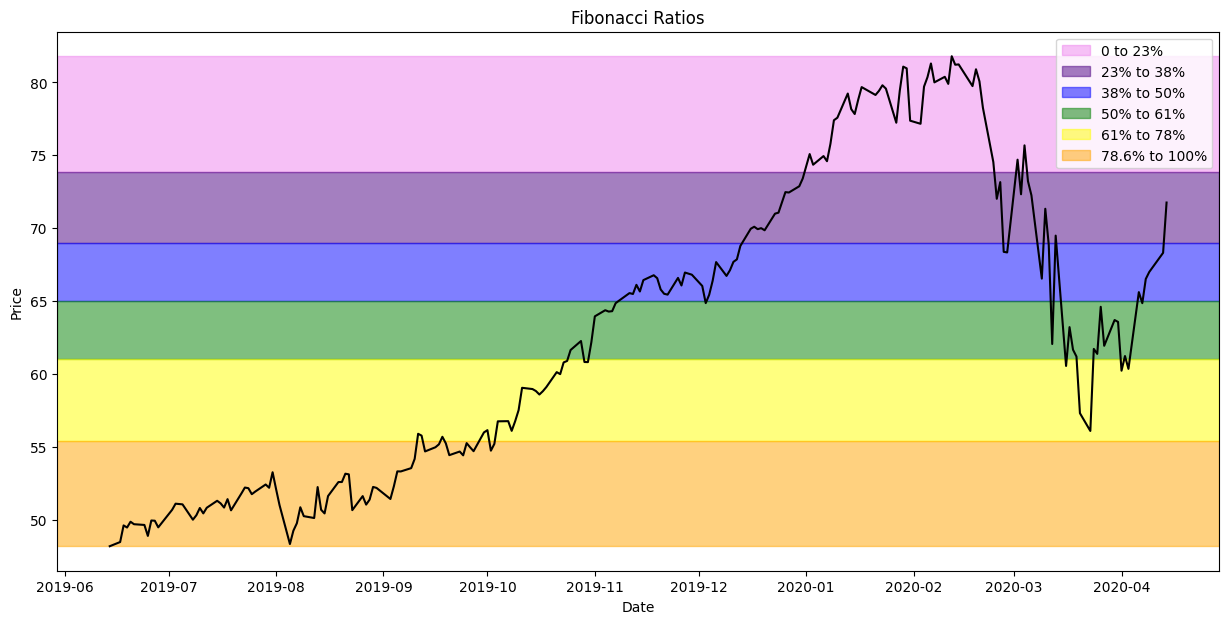

In [4]:
# Create common layouts for fibonacci ratios and close prices 
fig, ax = plt.subplots(figsize=(15, 7))

# Plot the close price of Apple stock
ax.plot(data.Close, color='black')

# Create the fibonacci ratio level between 0 and 23.6%
ax.axhspan(price_max, fib_23, alpha=0.5, color='violet', label='0 to 23%')

# Create the fibonacci ratio level between 23.6% and 38.2%
ax.axhspan(fib_23,fib_38, alpha=0.5, color='indigo', label='23% to 38%')

# Create the fibonacci ratio level between 38.2% and 50%
ax.axhspan(fib_38, fib_50, alpha=0.5, color='blue', label='38% to 50%')

# Create the fibonacci ratio level between 50% and 61.2%
ax.axhspan(fib_50, fib_61, alpha=0.5, color='green', label='50% to 61%')

# Create the fibonacci ratio level between 61.2% and 78.6%
ax.axhspan(fib_61, fib_78, alpha=0.5,
           color='yellow', label='61% to 78%')

# Create the fibonacci ratio level between 78.6% and 100%
ax.axhspan(fib_78, price_min, alpha=0.5,
           color='orange', label='78.6% to 100%')

# Plot the y-axis label
plt.ylabel("Price")

# Plot the x-axis label
plt.xlabel("Date")

# Plot the title
plt.title('Fibonacci Ratios')

# Display the legend
plt.legend()

# Plot the graph
plt.show()

You can see that a clear trend is present in the dataset, but the price moves down after reaching the maximum price. The price declines to the 50% level before reversing and moving upwards again. 

<a id='summary'></a>
## Summary

You have calculated and plotted the fibonacci ratios using the daily data of Apple stock. In the next section, you will use the fibonacci ratios to create a trading strategy. This strategy will use the fibonacci ratios for generating buy and sell signals based on the retracement of the price. Further, you will also perform some checks to identify and confirm a trend which is a necessary pre-requisite for the fibonacci retracement strategy to work. 